# 🌬 The Air You Breathe · Mapping NO₂ Pollution Across CDMX

**A space-based sensor reveals who breathes the worst air in the Mexico City metro area.**

*Notebook 3 of 8 -- Project: Dos Méxicos Bajo el Mismo Sol*  
*Author: Nelly Itzel Rodríguez Ortíz -- Last updated: 6 June 2026*


Notebook 01 showed us the heat. Notebook 02 showed us the concrete. Now we investigate the air itself. Is the less-green, hotter north also breathing more polluted air? Today we answer that -- by measuring nitrogen dioxide from space.


## What is NO₂?

**NO₂ = nitrogen dioxide**, a toxic gas with a reddish-brown tint in high concentrations (the brownish haze you sometimes see over a city). It forms whenever fuel burns at high temperature:

- Car and truck engines
- Factories and power plants
- Construction equipment
- Even gas stoves, in poorly ventilated kitchens

When we breathe it in, NO₂ irritates the lining of the lungs and throat. Long-term exposure is linked to **asthma, bronchitis, and reduced lung function** in children and adults. Mexico City's air-quality agency (CAM) has set hourly NO₂ limits, and on the worst days those limits are exceeded by a factor of two or three in the northern neighborhoods.

> 🍃 *If LST is the city's thermometer and NDVI is its chlorophyll detector, NO₂ is its pollution breathalyzer.*


## How Sentinel-5P measures NO₂

**Sentinel-5P** is a European Space Agency satellite carrying an instrument called **TROPOMI** -- the Tropospheric Monitoring Instrument. It orbits about **824 km above the Earth**, slightly higher than the International Space Station.

It does not sample air directly. Instead it plays a clever trick with **sunlight**:

1. Sunlight enters the atmosphere and travels down to the ground.
2. Along the way, gases like NO₂ absorb specific colors (wavelengths) of that light.
3. Some of the light bounces back up to the satellite.
4. By measuring which colors are *missing* in the reflected light, the satellite can calculate how much NO₂ was in the column of air the light passed through.

The product we use is the **tropospheric NO₂ column number density**, measured in **mol/m²** -- moles of NO₂ per square meter of ground.

> 💥 *Imagine a 1m x 1m square on the ground. Now imagine an invisible tube rising from that square up to 10 km (the top of the troposphere). How many NO₂ molecules are inside that tube? That's what we're mapping, for every square meter of the city.*


## Where the data comes from

| Source | What we get | Period |
|---|---|---|
| **Sentinel-5P TROPOMI** (ESA) | Tropospheric NO₂ column number density (mol/m²) | Full year 2025 (annual median) |
| **INEGI Marco Geoestadístico** | ZMVM boundaries (16 alcaldías + 60 EdoMex municipios) | 2020 |

The annual median is the key: it smooths out day-to-day noise. A single rainy day washes pollution out of the air; a single stagnant day can spike it. Averaging every cloud-free overpass in 2025 gives us the **background pollution pattern** -- the air a typical resident breathes over the long run.


## Building the pollution map, step by step

The pipeline mirrors Notebooks 01 and 02 in spirit, but the sensor is different:

1. **Collect** every Sentinel-5P overpass over the ZMVM in 2025.
2. **Filter for low cloud cover** using the `cloud_fraction` band (drop pixels with more than 30% cloud cover).
3. **Select the NO₂ band** (`tropospheric_NO2_column_number_density`).
4. **Take the annual median** -- one value per pixel, robust to outliers.
5. **Clip** to the ZMVM boundary.

The result is a single image: one NO₂ value, in mol/m², for every pixel in the metro area. All the heavy lifting (cloud masking, compositing, clipping) lives in the `src/` package. This notebook focuses on telling the story.


### ⚙️ One-time setup

The first time you run this notebook, uncomment the `ee.Authenticate()` line and follow the browser prompt. After that, the kernel remembers you for the session.


In [5]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   # so `import src` works from any CWD

import ee
import geemap

from src import (
    CDMX_CENTER, CDMX_ZOOM, EE_PROJECT_ID, NO2_VIS_PARAMS,
    get_norte_zmvm_aoi,
    get_sur_zmvm_aoi,
    get_zmvm_municipalities_aoi,
    load_no2_composite,
)

# ee.Authenticate()  # <- uncomment the first time
ee.Initialize(project=EE_PROJECT_ID)
print("\u2705 Earth Engine ready")


✅ Earth Engine ready


In [6]:
aoi_zmvm  = get_zmvm_municipalities_aoi()   # 16 CDMX alcaldias + 60 EdoMex municipios
aoi_norte = get_norte_zmvm_aoi()                # 6 features: concrete belt
aoi_sur   = get_sur_zmvm_aoi()                  # 6 features: green privilege

print("ZMVM features: ", aoi_zmvm.size().getInfo())
print("Norte features:", aoi_norte.size().getInfo())
print("Sur features:  ", aoi_sur.size().getInfo())


ZMVM features:  76
Norte features: 6
Sur features:   6


In [7]:
# Full year 2025 annual median. Cloud-masked (cloud_fraction < 0.3)
# inside load_no2_composite. Band name on the returned image: 'NO2_mol_m2'.
no2_2025 = load_no2_composite(
    aoi_zmvm,
    start_date="2025-01-01",
    end_date="2026-01-01",
    cloud_max=0.3,
)

print("Band names:", no2_2025.bandNames().getInfo())


Band names: ['NO2_mol_m2']


---

## 📊 NO₂ distribution across the ZMVM

Before mapping, let's look at the actual spread of NO₂ values across the metro area — this will help us choose a visualization range that reveals the pollution gradient.


In [8]:
# --- Step 1: Get the real stats from the NO2 image ---
raw_stats = no2_2025.reduceRegion(
    reducer=ee.Reducer.minMax().combine(
        ee.Reducer.percentile([5, 25, 50, 75, 95]), sharedInputs=True
    ),
    geometry=aoi_zmvm.geometry(),
    scale=1113,
    maxPixels=1e9,
).getInfo()

# Debug: show raw keys so we know the exact format
print("Raw keys from GEE:", list(raw_stats.keys()))

# GEE combined reducers may prefix keys with the band name.
# e.g. 'NO2_mol_m2_min' instead of just 'min'.
# We strip the prefix to get clean short names.
no2_stats = {}
for k, v in raw_stats.items():
    # Remove everything up to and including the last underscore
    # but only if it looks like a band prefix (contains 'NO2')
    if "NO2" in k and "_" in k:
        suffix = k.rsplit("_", 1)[-1]
    else:
        suffix = k
    no2_stats[suffix] = v

print("Cleaned keys:", list(no2_stats.keys()))

print("\nNO₂ distribution across ZMVM (mol/m²):")
print(f"  min  = {no2_stats['min']:.3e}")
print(f"  P5   = {no2_stats['p5']:.3e}")
print(f"  P25  = {no2_stats['p25']:.3e}")
print(f"  P50  = {no2_stats['p50']:.3e}  (median)")
print(f"  P75  = {no2_stats['p75']:.3e}")
print(f"  P95  = {no2_stats['p95']:.3e}")
print(f"  max  = {no2_stats['max']:.3e}")
print(f"\n  Current VIS_PARAMS: min={NO2_VIS_PARAMS['min']:.1e}, max={NO2_VIS_PARAMS['max']:.1e}")

# Compressed visualization range (P25–P95) for the maps below
COMPRESSED_VIS = {
    "min": no2_stats["p25"],
    "max": no2_stats["p95"],
    "palette": [
        "#1a9850",  # clean
        "#a6d96a",
        "#fee08b",
        "#f46d43",
        "#a50026",
        "#762a83",  # polluted
    ],
}


Raw keys from GEE: ['NO2_mol_m2_max', 'NO2_mol_m2_min', 'NO2_mol_m2_p25', 'NO2_mol_m2_p5', 'NO2_mol_m2_p50', 'NO2_mol_m2_p75', 'NO2_mol_m2_p95']
Cleaned keys: ['max', 'min', 'p25', 'p5', 'p50', 'p75', 'p95']

NO₂ distribution across ZMVM (mol/m²):
  min  = 1.222e-05
  P5   = 2.772e-05
  P25  = 4.097e-05
  P50  = 6.381e-05  (median)
  P75  = 9.658e-05
  P95  = 2.012e-04
  max  = 2.592e-04

  Current VIS_PARAMS: min=2.0e-05, max=2.5e-04


---

### 🗺️ Map 1 · The Big Picture: NO₂ across the full ZMVM

Using a **compressed scale (P25–P95)** to exaggerate the middle range and reveal the north–south gradient more clearly.


In [9]:
Map1 = geemap.Map(center=CDMX_CENTER, zoom=CDMX_ZOOM)

# Main raster layer: annual median NO2 (default on).
Map1.addLayer(no2_2025, COMPRESSED_VIS, "\U0001f32b\ufe0f NO\u2082 (mol/m\u00b2) -- Annual Median 2025")

# ZMVM boundary (top of the stack, easy to find).
Map1.addLayer(
    ee.Image().paint(aoi_zmvm, 0, 2), {"palette": ["black"]}, "ZMVM boundary",
)

# CDMX vs EdoMex municipio borders (off by default -- toggle them on
# when you want the political outline).
cdmx_outline  = aoi_zmvm.filter(ee.Filter.eq("entidad", "CDMX"))
edomex_outline = aoi_zmvm.filter(ee.Filter.eq("entidad", "EdoMex"))
Map1.addLayer(
    ee.Image().paint(cdmx_outline, 0, 1), {"palette": ["#ffffff"]},
    "CDMX municipio borders", False,
)
Map1.addLayer(
    ee.Image().paint(edomex_outline, 0, 1), {"palette": ["#ff7f00"]},
    "EdoMex municipio borders", False,
)

# Colorbar matching the NO2 palette in config.py.
Map1.add_colorbar(
    COMPRESSED_VIS,
    label="NO\u2082 (mol/m\u00b2)",
    layer_name="\U0001f32b\ufe0f NO\u2082 (mol/m\u00b2) -- Annual Median 2025",
)
Map1.add_layer_control()
Map1


Map(center=[19.4326, -99.1332], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topr…

> 🔍 **At this scale, the pollution pattern is clear.** A purple-red band stretches across the northern municipios, while greens and yellows dominate the south. The same geographic divide we saw in temperature and vegetation reappears in air quality.


---

### 🗺️ Map 2 · The Pollution Belt: Northern CDMX and its periphery

The same compressed scale reveals the pollution gradient across the six northern municipios.


In [10]:
# Dynamic center from the northern AOI
norte_center = aoi_norte.geometry().centroid(maxError=10).getInfo()['coordinates']

Map2 = geemap.Map(center=[norte_center[1], norte_center[0]], zoom=12)

# Annual median NO2 over the concrete belt.
Map2.addLayer(no2_2025, COMPRESSED_VIS, "\U0001f32b\ufe0f NO\u2082 (mol/m\u00b2) -- Annual Median 2025")

# Municipio outlines + name labels (the "labels" widget writes NOMGEO on the map).
Map2.addLayer(
    ee.Image().paint(aoi_norte, 0, 2), {"palette": ["black"]},
    "Municipality borders",
)
Map2.add_labels(aoi_norte, "NOMGEO", font_size="11pt", font_color="black")

Map2.add_colorbar(
    COMPRESSED_VIS,
    label="NO\u2082 (mol/m\u00b2)",
    layer_name="\U0001f32b\ufe0f NO\u2082 (mol/m\u00b2) -- Annual Median 2025",
)
Map2.add_layer_control()
Map2


Map(center=[19.482804060686934, -99.12852972316033], controls=(WidgetControl(options=['position', 'transparent…

> 🔍 **This is the air that millions of people breathe every day.** Naucalpan, Tlalnepantla, Gustavo A. Madero, Iztapalapa and Nezahualcoyolt form a nearly uninterrupted belt of severe NO₂ pollution. These are the same neighborhoods that were 5-8 °C hotter in Notebook 01 and pale yellow (concrete) in Notebook 02.


---

### 🗺️ Map 3 · The Green South: Southern CDMX alcaldías

The same compressed scale in the greener south shows how lower NO₂ levels create a cooler color signature.


In [11]:
# Dynamic center from the southern AOI
sur_center = aoi_sur.geometry().centroid(maxError=10).getInfo()['coordinates']

Map3 = geemap.Map(center=[sur_center[1], sur_center[0]], zoom=11)

Map3.addLayer(no2_2025, COMPRESSED_VIS, "🌫️ NO₂ (mol/m²) — Annual Median 2025")

Map3.addLayer(
    ee.Image().paint(aoi_sur, 0, 2), {"palette": ["black"]},
    "Municipality borders",
)
Map3.add_labels(aoi_sur, "NOMGEO", font_size="11pt", font_color="black")

Map3.add_colorbar(
    COMPRESSED_VIS,
    label="NO₂ (mol/m²)",
    layer_name="🌫️ NO₂ (mol/m²) — Annual Median 2025",
)
Map3.add_layer_control()
Map3


Map(center=[19.25293136793208, -99.2048956452334], controls=(WidgetControl(options=['position', 'transparent_b…

> 🔍 **The southern alcaldías show consistently lower NO₂ — more greens and yellows, fewer reds and purples.** Coyoacán and Tlalpan benefit from vegetation cover and less industrial activity, while Cuajimalpa and Xochimilco sit at the cleaner edge of the metro area.


## ⚖️ North vs south: the pollution gap in numbers

We use the same municipio groups as Notebooks 01 and 02 so the cross-notebook numbers stay comparable:

- **Nororiente (hotter in LST, less green in NDVI):** Gustavo A. Madero, Iztapalapa, Ecatepec de Morelos, Tlalnepantla de Baz, Nezahualcóyotl
- **Sur (cooler in LST, greener in NDVI):** Coyoacán, Álvaro Obregón, Tlalpan, La Magdalena Contreras


In [12]:
# Same municipio groups as Notebooks 01 and 02, so the cross-notebook
# numbers stay apples-to-apples.
nororiente_names = [
    "Gustavo A. Madero", "Iztapalapa", "Ecatepec de Morelos",
    "Tlalnepantla de Baz", "Nezahualcoyotl",
]
sur_names = [
    "Coyoacán", "Álvaro Obregón", "Tlalpan", "La Magdalena Contreras",
]

nororiente = aoi_zmvm.filter(ee.Filter.inList("NOMGEO", nororiente_names))
sur        = aoi_zmvm.filter(ee.Filter.inList("NOMGEO", sur_names))

def mean_no2(image, fc):
    '''Mean NO2 in mol/m2 over the dissolved geometry. S5P L3 native
    resolution is ~1113 m, so we sample at that scale.'''
    result = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=fc.geometry().dissolve(),
        scale=1113, maxPixels=1e9,
    ).getInfo()
    # Robust access: try band name first, then fall back to first value
    if "NO2_mol_m2" in result:
        return result["NO2_mol_m2"]
    return list(result.values())[0]

m_norte = mean_no2(no2_2025, nororiente)
m_sur   = mean_no2(no2_2025, sur)
gap     = m_norte - m_sur

# Express the gap as a percentage relative to the southern (cleaner) baseline
# to make the inequality visible at a glance.
pct_gap = 100.0 * gap / m_sur if m_sur else float("nan")

print(f"North (nororiente) mean NO\u2082: {m_norte:.3e} mol/m\u00b2")
print(f"South (sur)        mean NO\u2082: {m_sur:.3e} mol/m\u00b2")
print(f"Absolute gap:                  {gap:+.3e} mol/m\u00b2")
print(f"Relative gap (vs south):       {pct_gap:+.1f} %")


North (nororiente) mean NO₂: 1.632e-04 mol/m²
South (sur)        mean NO₂: 1.323e-04 mol/m²
Absolute gap:                  +3.090e-05 mol/m²
Relative gap (vs south):       +23.4 %


## 🔗 Connecting the dots: NDVI and NO₂

In Notebook 02 we saw that the north has far less vegetation. In the maps above, the north has more NO₂. Are the two patterns the same pattern?

To answer that, we sample (NDVI, NO₂) pairs across the metro area and look at the correlation. We do it at three scales -- the same three-scale setup as Notebook 02 -- because the strength of the relationship depends on **where you look**, and that, more than the correlation itself, is what the rest of this project leans on:

- **Scale 1 -- The Pollution Belt:** CDMX + the 4 northern EdoMex municipios.
- **Scale 2 -- The Cleaner Air:** CDMX + the 6 southern alcaldías.
- **Scale 3 -- The Big Picture:** the full 76-municipio ZMVM.

400 random points per scale, seed=42, native S5P resolution (1113 m).


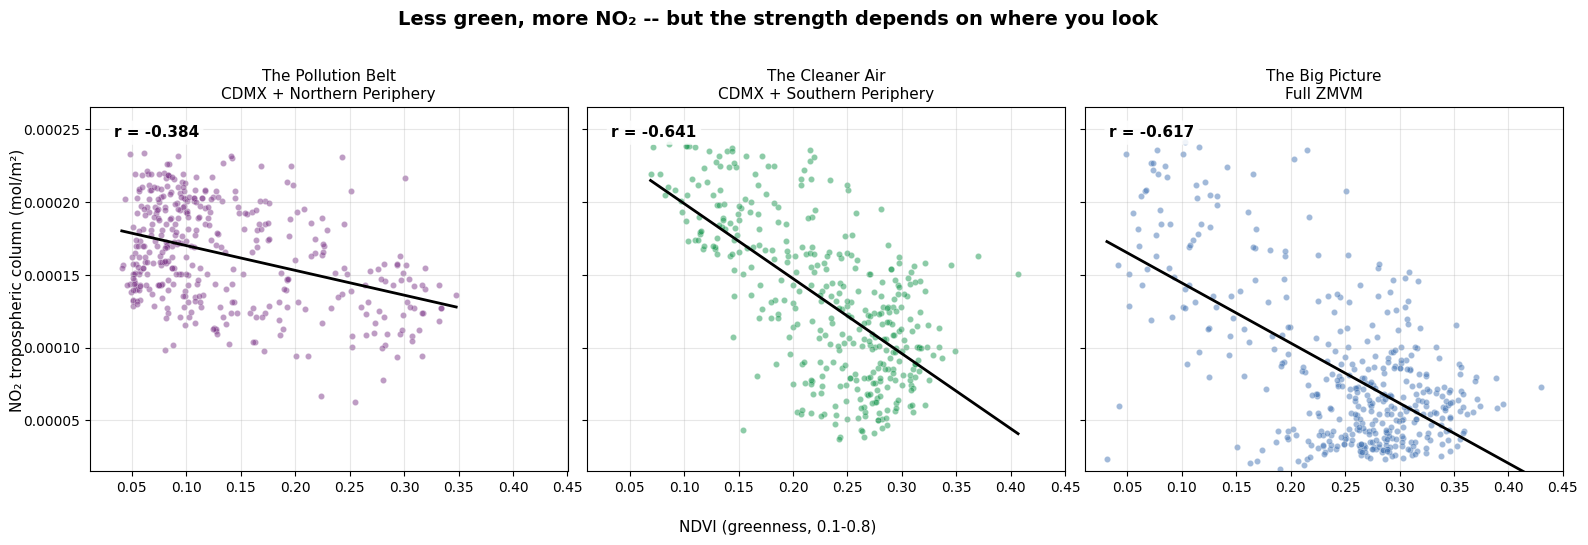


NDVI-NO₂ Pearson r by scale:
  The Pollution Belt CDMX + Northern Periphery       r = -0.384
  The Cleaner Air CDMX + Southern Periphery          r = -0.641
  The Big Picture Full ZMVM                          r = -0.617


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import load_ndvi_composite

# We need NDVI and NO2 sampled on the same grid. The coarser of the two
# is S5P L3 NO2 (~1113 m), so we sample at that scale to avoid
# pseudo-replication of NO2 pixels.
ndvi_summer = load_ndvi_composite(
    aoi_zmvm, start_date="2025-06-01", end_date="2025-09-01", cloud_max=20.0,
)
stacked = ndvi_summer.addBands(no2_2025)

def sample_ndvi_no2(aoi, n=400, seed=42, scale=1113):
    '''n random (NDVI, NO2) pairs from the stacked image, masked pixels dropped.'''
    samples = stacked.sample(
        region=aoi.geometry(),
        scale=scale, numPixels=n, seed=seed, geometries=False,
    ).getInfo()
    return pd.DataFrame(
        [f["properties"] for f in samples["features"]]
    ).dropna()

df_norte = sample_ndvi_no2(get_norte_zmvm_aoi())
df_sur   = sample_ndvi_no2(get_sur_zmvm_aoi())
df_zmvm  = sample_ndvi_no2(aoi_zmvm)

# Shared axes so the three panels are directly comparable.
all_ndvi = pd.concat([df_norte["NDVI"], df_sur["NDVI"], df_zmvm["NDVI"]])
all_no2  = pd.concat([df_norte["NO2_mol_m2"], df_sur["NO2_mol_m2"], df_zmvm["NO2_mol_m2"]])
x_min, x_max = all_ndvi.min() - 0.02, all_ndvi.max() + 0.02
y_min, y_max = all_no2.min()  * 0.9, all_no2.max() * 1.1

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharex=True, sharey=True)

scales = [
    ("The Pollution Belt\nCDMX + Northern Periphery", df_norte, "#7f3b8b"),  # purple
    ("The Cleaner Air\nCDMX + Southern Periphery",    df_sur,   "#1a9850"),  # green
    ("The Big Picture\nFull ZMVM",                    df_zmvm,  "#4575b4"),  # blue
]

for ax, (title, df, color) in zip(axes, scales):
    ax.scatter(
        df["NDVI"], df["NO2_mol_m2"],
        s=20, alpha=0.5, color=color,
        edgecolor="white", linewidth=0.3,
    )
    coef = np.polyfit(df["NDVI"], df["NO2_mol_m2"], 1)
    xfit = np.linspace(df["NDVI"].min(), df["NDVI"].max(), 100)
    ax.plot(xfit, np.polyval(coef, xfit), color="black", linewidth=2.0)
    r = df["NDVI"].corr(df["NO2_mol_m2"])
    ax.text(
        0.05, 0.95, f"r = {r:+.3f}",
        transform=ax.transAxes, va="top", ha="left",
        fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  alpha=0.85, edgecolor="none"),
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    "Less green, more NO\u2082 -- but the strength depends on where you look",
    fontsize=14, fontweight="bold", y=1.02,
)
fig.supxlabel("NDVI (greenness, 0.1-0.8)", fontsize=11)
fig.supylabel("NO\u2082 tropospheric column (mol/m\u00b2)", fontsize=11)

plt.tight_layout()
plt.show()

print("\nNDVI-NO\u2082 Pearson r by scale:")
for title, df, _ in scales:
    r = df["NDVI"].corr(df["NO2_mol_m2"])
    print(f"  {title.replace(chr(10), ' '):50s} r = {r:+.3f}")


> 💡 **Interpreting the correlation:** r = -0.384 (Pollution Belt) means a moderate negative relationship: as vegetation goes up, NO₂ tends to go down — but other factors (traffic density, industry, wind patterns) also play a role. The relationship is stronger in the Cleaner Air zone (r = -0.641) and across the full ZMVM (r = -0.617), where the contrast between green south and industrial north is more pronounced.


---

## 📊 The three burdens side by side

Putting it all together — the same geographic divide (north vs south) across all three environmental indicators:


In [14]:
import pandas as pd
from IPython.display import display

summary = pd.DataFrame({
    "Indicator": [
        "🌡️ LST — Summer (°C)",
        "🌡️ LST — Winter (°C)",
        "🌿 NDVI — Summer",
        "🌿 NDVI — Winter",
        "🌫️ NO₂ (mol/m²)",
    ],
    "North (nororiente)": [
        "36.6",
        "28.5",
        "0.122",
        "0.068",
        "1.632e-04",
    ],
    "South (sur)": [
        "26.0",
        "21.6",
        "0.233",
        "0.163",
        "1.323e-04",
    ],
    "Gap": [
        "+10.6 °C",
        "+6.8 °C",
        "−0.111",
        "−0.095",
        "+3.090e-05 (+23.4%)",
    ],
    "Notebook": [
        "01",
        "01",
        "02",
        "02",
        "03",
    ],
})

display(summary)


,Indicator,North (nororiente),South (sur),Gap,Notebook
0,🌡️ LST — Summer (°C),36.6,26.0,+10.6 °C,01
1,🌡️ LST — Winter (°C),28.5,21.6,+6.8 °C,01
2,🌿 NDVI — Summer,0.122,0.233,−0.111,02
3,🌿 NDVI — Winter,0.068,0.163,−0.095,02
4,🌫️ NO₂ (mol/m²),1.632e-04,1.323e-04,+3.090e-05 (+23.4%),03


> 🔑 **The pattern is consistent across every indicator:** the northern ZMVM is hotter, less green, and more polluted than the south. This is the **triple burden** — heat, lack of vegetation, and air pollution — concentrated on the same communities.


## 🔑 Key finding

> **The less-green north is also the more polluted north.** Across the ZMVM, the neighborhoods with the lowest NDVI are systematically exposed to the highest NO₂ levels. The environmental burdens -- heat, lack of trees, and air pollution -- fall on the same communities.


## 🧍‍♀️ What the colors mean, in human terms

Purple on this map isn't just a color. It's the air that a child with asthma breathes on the walk to school. It's the invisible irritant that sends an elderly neighbor to the emergency room on a bad-air day. It's the reason a street vendor develops a chronic cough. The highest NO₂ levels don't follow a simple north–south line — they cluster in the areas where economic activity is most intense: **Gustavo A. Madero, Álvaro Obregón, Coyoacán**, and parts of **Naucalpan and Tlalnepantla**. These are the neighborhoods where jobs are concentrated, where traffic converges every morning, and where industry and warehouses sit alongside homes. The pollution follows the commute — not the compass.

This is the face of environmental injustice: the burden is **compounded**, not spread evenly. The same families who endure the hottest nights and the least shade are also the ones with the most polluted air.


## 🔎 What we know, and what we don't

✅ **Confirmed in this notebook:**

- The northern ZMVM has significantly higher NO₂ than the south.
- NO₂ hotspots overlap with low-NDVI areas from Notebook 02 and high-LST areas from Notebook 01.
- The **triple burden** pattern is emerging: heat + no trees + polluted air hit the same neighborhoods.

❓ **Still open questions:**

- Satellites measure the entire air column. What about pollution at street level, where people actually breathe? → **Notebook 4: PM₂.₅ and PM₁₀ from Ground Monitors**
- Are these polluted, hot, treeless neighborhoods also the poorest? → **Notebook 5: Marginalization**
- Does breathing this air make people sick? → **Notebook 6: Respiratory Health**
- Do residents themselves perceive this? → **Notebook 7: Perception Survey**

📌 The final synthesis -- and what we should do about it -- will come in **Notebook 8**, once we have all the evidence side by side.

---

### 📚 Learn more

- ESA Sentinel-5P mission: https://www.esa.int/Applications/Observing_the_Earth/Copernicus/Sentinel-5P
- TROPOMI NO₂ product: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_OFFL_L3_NO2
- INEGI Marco Geoestadístico: https://www.inegi.org.mx/temas/mg/

### 🛠️ About the code

- All reusable helpers live in the `src/` package (`aoi.py`, `sentinel5p.py`, `config.py`, `visualization.py`).
- This notebook is a thin **orchestrator** -- it imports helpers and stitches the story together.
- The `src/` package is installed in editable mode (`pip install -e .`); any edit to a helper is immediately reflected here.

---

➡️ **Next notebook:** *Street-Level Pollution -- PM₂.₅ and PM₁₀ from Ground Monitors*
